In [1]:
"""
bimodal, multinn, multilayer, circle-square, arctan threshold
small images, reduced number of units to 2
"""

'\nbimodal, multinn, multilayer, circle-square, arctan threshold\nsmall images, reduced number of units to 2\n'

In [2]:
import os
import sys

# Add the project's root directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import argparse
import random
import time
import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import copy
import torchvision
import warnings
import math
import matplotlib.pyplot as plt


from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.optim.optimizer import Optimizer, required
from torch.optim.lr_scheduler import StepLR

%matplotlib inline

warnings.filterwarnings('ignore')

## Install R package BayesGPfit

from GP_comp.GP import gp_eigen_value, gp_eigen_funcs_fast, generate_grids

from simulate_data import simulate_data_circle_square
from utils import generate_linear_data, plot_mse, plot_sigma_squared, plot_image
from torch.utils.data import Dataset, DataLoader
import torch
from torch.utils.data import Dataset
from sklearn.metrics import confusion_matrix, precision_score
import numpy as np

## 1. Model

### 1.1  BNNSTGP

In [3]:
from utils import sample_inverse_gamma
class multimodal(nn.Module):
    def __init__(self, input_dim, n_hid_list, output_dim, w_dim, n_knots, phi1, phi2, eigenvalues, nu_tilde1 = 1., nu_tilde2 = 1., act='relu'):
        super(multimodal, self).__init__()
        self.nn1 = BNNSTGP_one_layer(input_dim=input_dim, n_hid_list=n_hid_list, output_dim=output_dim, 
                    w_dim=w_dim, n_knots = n_knots, phi=phi1, eigenvalues=eigenvalues,
                    nu_tilde = nu_tilde1, act = act)
        self.nn2 = BNNSTGP_one_layer(input_dim=input_dim, n_hid_list=n_hid_list, output_dim=output_dim, 
                    w_dim=w_dim, n_knots = n_knots, phi=phi2, eigenvalues=eigenvalues,
                    nu_tilde = nu_tilde2, act = act)
        
        # I used the following line as the initial value for sigma_squared, 
        # value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        # However, Guoxuan said the initial value of sigma_squared can be set at 1.0 for now.
        self.sigma_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)

    def forward(self, x1, x2, w):
        return self.nn1(x1, w) + self.nn2(x2, w)

    def log_prior(self):
        return self.nn1.log_prior() + self.nn2.log_prior()

    def sample_and_set_sigma_squared(self, n, loss, a=1000, b=1.0):
        with torch.no_grad():
            new_a = a + n / 2.0
            new_b = b + loss / 2.0
            sigma_squared = sample_inverse_gamma(new_a, new_b, size=1).squeeze()
            self.sigma_squared.copy_(sigma_squared)
            return self.sigma_squared
    def sample_and_set_sigma_lambda_squared(self, a_lambda=2.0, b_lambda=1.0):
        self.nn1.sample_and_set_sigma_lambda_squared()
        self.nn2.sample_and_set_sigma_lambda_squared()

    def sample_and_set_sigma_theta_squared(self, a_theta=2.0, b_theta=1.0):
        self.nn1.sample_and_set_sigma_theta_squared()
        self.nn2.sample_and_set_sigma_theta_squared()

In [4]:
## BNNSTGP Model
from utils import sample_inverse_gamma

class BNNSTGP_one_layer(nn.Module):
    def __init__(self, input_dim, n_hid_list, output_dim, w_dim, n_knots, phi, eigenvalues, nu_tilde = 1., act='relu'):
        super(BNNSTGP_one_layer, self).__init__()

        self.input_dim = input_dim
        self.n_hid_list = n_hid_list
        self.output_dim = output_dim
        self.w_dim = w_dim
        self.n_knots = n_knots
        self.phi = phi
        self.eigenvalues=torch.tensor(eigenvalues, dtype=torch.float32)
        
        values = torch.randn(n_hid_list[0], n_knots) * self.eigenvalues
        self.cu = nn.Parameter(values.T)
        self.TOTAL_ENTRIES_OF_CU = self.cu.numel()

        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        # However, Guoxuan said the initial value of sigma_squared can be set at 1.0 for now.
        self.sigma_theta_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        # However, Guoxuan said the initial value of sigma_squared can be set at 1.0 for now.
        self.sigma_lambda_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        self.nu_tilde = nu_tilde
        
        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        # However, Guoxuan said the initial value of sigma_squared can be set at 1.0 for now.
        self.sigma_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        if act == 'relu':
            self.act = nn.ReLU()
        elif act == 'tanh':
            self.act = nn.Tanh()
        elif act == 'sigmoid':
            self.act = nn.Sigmoid()
        else:
            raise ValueError('Invalid activation function %s' % act)

        #create one flat parameter so all other operations stay the same
        total_params = 0
        current_size = n_hid_list[0]
        for i in range(1, len(n_hid_list)):
            total_params += current_size * n_hid_list[i] + n_hid_list[i]
            current_size = n_hid_list[i]
        total_params += current_size * output_dim + output_dim
        self.fully_connected_nn = nn.Parameter(torch.Tensor(total_params).normal_(0, math.sqrt(self.sigma_theta_squared.item())))

        # store architecture info
        self.fc_arch = n_hid_list.copy()
        self.fc_arch.append(output_dim)

        # helper lists for forward pass
        self._fc_weights = []
        self._fc_biases = []
        self._setup_fc_layers()
        
        self.ksi = nn.Parameter(torch.Tensor(n_hid_list[0]).normal_(0, math.sqrt(self.sigma_theta_squared.item())))
        self.NUM_PARAMS = self.count_num_params()

    def _setup_fc_layers(self):
        #purpose of this function is to reshape fully_connected_nn into multiple layers for forward pass
        idx = 0
        input_size = self.n_hid_list[0]
        
        for i, output_size in enumerate(self.fc_arch[1:]):
            weight_size = input_size * output_size
            weight = self.fully_connected_nn[idx:idx + weight_size].reshape(input_size, output_size)
            self._fc_weights.append(weight)
            idx += weight_size
            
            bias = self.fully_connected_nn[idx:idx + output_size]
            self._fc_biases.append(bias)
            idx += output_size
            
            input_size = output_size

    def forward(self, x, w, mode = "train"):
        out = torch.mm(self.phi, self.cu)
        if mode == "train":
            out = self.soft_threshold_approximation(out, self.nu_tilde)
        elif mode == "inference":
            out = self.soft_threshold(out, self.nu_tilde)
        else:
            raise ValueError('mode can only be one of train or inference')
        out = torch.sqrt(self.sigma_lambda_squared) * out
        out = torch.mm(x, out) + self.ksi
        out = self.act(out)
        
        for i, (weight, bias) in enumerate(zip(self._fc_weights, self._fc_biases)):
            #multiply each layer and add bias one by one
            out = torch.mm(out, weight) + bias
            if i < len(self._fc_weights) - 1: 
                out = self.act(out)
        
        return out


    def log_prior(self):
        logprior = 0.5 * (self.cu ** 2).sum() / self.sigma_lambda_squared
        logprior += 0.5 * (self.fully_connected_nn ** 2).sum() / self.sigma_theta_squared
        logprior += 0.5 * (self.ksi ** 2).sum() / self.sigma_theta_squared
        return logprior

    def count_num_params(self):
        count = 0
        count += self.ksi.numel()
        count += self.fully_connected_nn.numel() 
        return count
        
    def sample_and_set_sigma_squared(self, n, loss, a=1000, b=1.0):
        with torch.no_grad():
            new_a = a + n / 2.0
            new_b = b + loss / 2.0
            sigma_squared = sample_inverse_gamma(new_a, new_b, size=1).squeeze()
            self.sigma_squared.copy_(sigma_squared)
            return self.sigma_squared

    def sample_and_set_sigma_lambda_squared(self, a_lambda=2.0, b_lambda=1.0):
        with torch.no_grad():
            new_a_lambda = a_lambda + self.TOTAL_ENTRIES_OF_CU / 2.0
            new_b_lambda = b_lambda + torch.sum(self.cu ** 2) / 2.0
            sigma_lambda_squared = sample_inverse_gamma(new_a_lambda, new_b_lambda, size=1).squeeze()
            self.sigma_lambda_squared.copy_(sigma_lambda_squared)
            return self.sigma_lambda_squared

    def sample_and_set_sigma_theta_squared(self, a_theta=2.0, b_theta=1.0):
        """
        Sample σβ^2 from an Inverse-Gamma distribution using equation (21), with data dependency via β^T β.
        Returns:
            torch.Tensor: Sampled σβ^2 from the Inverse-Gamma distribution.
        """
        with torch.no_grad():
            new_a_theta = a_theta + self.NUM_PARAMS / 2.0
            new_b_theta = b_theta + torch.sum(self.fully_connected_nn ** 2) / 2.0 + torch.sum(self.ksi ** 2) / 2.0

            sigma_theta_squared = sample_inverse_gamma(new_a_theta, new_b_theta, size=1).squeeze()
            self.sigma_theta_squared.copy_(sigma_theta_squared)
            return self.sigma_theta_squared

    def step_approximation(self, x, steep):
        return (1 / 2 + 1 / np.pi * torch.arctan(steep * x))
    
    def soft_threshold(self, x, nu_tilde):
        return F.threshold(x, nu_tilde, nu_tilde) - F.threshold(-x, nu_tilde, nu_tilde)
    
    def soft_threshold_approximation(self, x, nu_tilde, steep = 100):
        return (x - nu_tilde) * self.step_approximation(x - nu_tilde, steep) + (x + nu_tilde) * self.step_approximation(- x - nu_tilde, steep)

### 1.2 SGLD 

In [5]:
## SGLD (Stochastic Gradient Langevin Dynamics)

class SGLD(Optimizer):
    def __init__(self, params, lr = required, langevin = True):
        self.langevin = langevin
        defaults = dict(lr=lr)
        super(SGLD, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        loss = None
        
        for group in self.param_groups:
            
            for p in group['params']:
                if p.grad is None:
                    continue
                d_p = p.grad
                
                if self.langevin == True:
                    langevin_noise = p.new(p.size()).normal_(mean=0, std=1)/np.sqrt(group['lr'])
                    p.add_(0.5*d_p + langevin_noise, alpha = -group['lr'])

                else:
                    p.add_(0.5*d_p, alpha = -group['lr'])


        return loss


### 1.3 Network Wrapper

In [6]:

## Network Wrapper

class Net(object):

    def __init__(self, task='binary', lr=1e-3, input_dim=784, n_hid_list = [32,32], output_dim = 1, w_dim = 1, n_knots = 66,
                 N_train=200, phi1=None, phi2 = None, eigenvalues=None, nu_tilde1 = 1, nu_tilde2 = 1, langevin = True, step_decay_epoch = 100, step_gamma = 0.1, act = 'relu'):
        
        #print(' Creating Net!! ')
        self.task = task
        if task not in ['binary', 'multiclass', 'regression']:
            raise ValueError('Invalid task %s' % task)
        self.lr = lr

        self.input_dim = input_dim
        self.n_hid_list = n_hid_list
        self.output_dim = output_dim
        self.w_dim = w_dim
        
        self.n_knots = n_knots
        self.phi1 = phi1
        self.phi2 = phi2
        self.eigenvalues = eigenvalues
        self.nu_tilde1 = nu_tilde1
        self.nu_tilde2 = nu_tilde2
        self.act = act

        self.N_train = N_train
        self.langevin = langevin
        self.step_decay_epoch = step_decay_epoch
        self.step_gamma = step_gamma

        self.create_net()
        self.create_opt()
        self.epoch = 0
        
        self.weight_set_samples = []
        self.r2_train = []
        self.r2_test = []

    def create_net(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = multimodal(input_dim=self.input_dim, n_hid_list=self.n_hid_list, output_dim=self.output_dim, 
                            w_dim=self.w_dim, n_knots = self.n_knots, phi1=torch.tensor(self.phi1).to(self.device),
                            phi2=torch.tensor(self.phi2).to(self.device), eigenvalues=self.eigenvalues,
                            nu_tilde1 = self.nu_tilde1, nu_tilde2 = self.nu_tilde2, act = self.act)
        self.model.to(self.device)


    def create_opt(self):
        self.optimizer = SGLD(params=self.model.parameters(), lr=self.lr, langevin = self.langevin)
        self.scheduler = StepLR(self.optimizer, step_size = self.step_decay_epoch, gamma=self.step_gamma)


    def fit(self, x1, x2, w, y, threshold=0.5):
        x1 = x1.to(self.device)
        x2 = x2.to(self.device)
        w = w.to(self.device)

        if self.task == 'binary':
            y = y.float().to(self.device).reshape(-1, 1)
            self.optimizer.zero_grad()

            out = self.model(x1, x2, w)
            loss = F.binary_cross_entropy_with_logits(out, y, reduction='mean')
            loss = loss * self.N_train 
            #loss += self.model.log_prior()
            
            loss.backward()
            self.optimizer.step() 

            pred = (torch.sigmoid(out)>threshold).long()
            accu = (pred == y.long()).sum().float()
        elif self.task == 'regression':
            y = y.float().to(self.device).reshape(-1, 1)
            self.optimizer.zero_grad()

            out = self.model(x1, x2, w)
            mse_loss = F.mse_loss(out, y, reduction='mean')
            self.r2_train.append(1 - mse_loss.detach().item() / torch.var(y).item())
            adjusted_loss = mse_loss * self.N_train / self.model.sigma_squared / 2.0
            total_loss = adjusted_loss + self.model.log_prior()
            
            total_loss.backward()
            self.optimizer.step() 

            pred = 0.0
            accu = 0.0
            return mse_loss, accu 

        else:                           ## multiclass
            y = y.long().to(self.device).reshape(-1)
            self.optimizer.zero_grad()

            out = self.model(x, w)
            loss = F.cross_entropy(out, y, reduction = 'mean')
            loss = loss * self.N_train

            loss += self.model.log_prior()
            
            loss.backward()
            self.optimizer.step()

            pred = out.max(dim=1, keepdim=False)[1]
            accu = (pred == y).sum()

        return loss*x.shape[0]/self.N_train, accu
    

    def get_nb_parameters(self):
        return sum(p.numel() for p in self.model.parameters())


    def save_net_weights(self, max_samples):
        
        if len(self.weight_set_samples) >= max_samples:
            self.weight_set_samples.pop(0)
            
        self.weight_set_samples.append(copy.deepcopy(self.model.state_dict()))
        #print(' saving weight samples %d/%d' % (len(self.weight_set_samples), max_samples) )


    def all_sample_eval(self, x1, x2, w, y, threshold=0.5):
        with torch.no_grad():
            x1 = x1.to(self.device)
            x2 = x2.to(self.device)
            w = w.to(self.device)
            y = y.float().to(self.device).reshape(-1, 1)
            self.optimizer.zero_grad()

            out = self.model(x1, x2, w)
            mse_loss = F.mse_loss(out, y, reduction='mean')
            self.r2_test.append(1 - mse_loss.detach().item() / torch.var(y).item())

            pred = 0.0
            accu = 0.0
            return mse_loss, accu 


    def save(self, filename):
        print('Writting %s\n' % filename)
        torch.save({
            'epoch': self.epoch,
            'lr': self.lr,
            'model': self.model,
            'optimizer': self.optimizer,
            'scheduler': self.scheduler}, filename)

    def load(self, filename):
        print('Reading %s\n' % filename)
        state_dict = torch.load(filename)
        self.epoch = state_dict['epoch']
        self.lr = state_dict['lr']
        self.model = state_dict['model']
        self.optimizer = state_dict['optimizer']
        self.scheduler = state_dict['scheduler']
        print('  restoring epoch: %d, lr: %f' % (self.epoch, self.lr))
        return self.epoch


## 2. Load sythntic Data by Guoxuan

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset

class mydata(Dataset):
    def __init__(self, x1_list, x2_list, y_list):
        self.x1_list = x1_list
        self.x2_list = x2_list
        self.y_list = y_list
    def __len__(self):
        return len(self.y_list)
    def __getitem__(self, i):
        x1 = self.x1_list[i].reshape(-1)
        x2 = self.x2_list[i].reshape(-1)
        w = torch.tensor([1.])
        y = torch.tensor([self.y_list[i]])
        return (x1, x2, w), y

def create_dataloaders(X1, X2, y, val_ratio=0.2, batch_size=32, shuffle=True):
    """
    Splits X, y into training and validation DataLoaders.
    
    Args:
        X (torch.Tensor): Feature tensor, shape (n_samples, n_features).
        y (torch.Tensor): Target tensor, shape (n_samples,).
        val_ratio (float): Proportion of dataset to use for validation (default=0.2).
        batch_size (int): Batch size for DataLoader (default=32).
        shuffle (bool): Whether to shuffle the dataset before splitting (default=True).
    
    Returns:
        train_loader (DataLoader), val_loader (DataLoader)
    """
    # Wrap tensors into a TensorDataset
    dataset = mydata(X1, X2, y)
    
    # Calculate sizes
    n_samples = len(dataset)
    n_val = int(n_samples * val_ratio)
    n_train = n_samples - n_val
    
    # Random split
    train_dataset, val_dataset = random_split(dataset, [n_train, n_val])
    # train_y_mean = train_dataset.y.mean()
    # train_y_std = train_dataset.y.std()

    # #scaling the data
    # train_dataset.y = scale_data(train_dataset, train_y_mean, train_y_std)
    # val_dataset.y = scale_data(val_dataset, train_y_mean, train_y_std)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, n_train, n_val



## 3. Training using full data

In [8]:
class MNIST_runner:
    def __init__(self, train_loader, val_loader, lr = 5e-7, a_for_eigen=0.0001, b_for_eigen = 20, nu_tilde1 = 2.5, nu_tilde2 = 2.5, 
                 langevin = True, seed = 17, act = 'relu', in_feature1=100, in_feature2=200, hidden_unit_list=[32,32]):
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.lr = lr
        self.b_for_eigen = b_for_eigen
        self.nu_tilde1 = nu_tilde1
        self.nu_tilde2 = nu_tilde2
        self.langevin = langevin
        self.seed = seed
        self.act = act
        self.curr_epoch = 0
        self.total_epochs = 0
        
        self.start_save = 0
        self.save_every = 2
        self.N_saves = 100
        self.test_every = 10
        self.print_every = 10
        
        self.loss_train = []
        self.accu_train = []
        self.loss_val = []
        self.accu_val = []

        self.n_hid_list = hidden_unit_list

        grids1 = generate_grids(dimensions=2, num_grids=in_feature1)
        phi1 = gp_eigen_funcs_fast(grids1, poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        phi1 = np.array(phi1)
        
        grids2 = generate_grids(dimensions=2, num_grids=in_feature2)
        phi2 = gp_eigen_funcs_fast(grids2, poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        phi2 = np.array(phi2)
        
        eigenvalues_np = gp_eigen_value(poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        #phi = phi * np.sqrt(eigenvalues_np)
        torch.set_default_dtype(torch.float32)

        self.net = Net(lr=lr, input_dim=in_feature1*in_feature1, n_hid_list = self.n_hid_list, output_dim = 1, w_dim = 1, n_knots = phi1.shape[1],
            N_train=len(self.train_loader.dataset.indices), phi1=torch.tensor(phi1, dtype=torch.float32), phi2=torch.tensor(phi2, dtype=torch.float32), 
            eigenvalues=eigenvalues_np, nu_tilde1 = nu_tilde1, nu_tilde2 = nu_tilde2, langevin=langevin,
            step_decay_epoch = 50, step_gamma = 0.5, act = act, task='regression')
        
    def calculate_beta(self, burnin = 0.5):
        betas1= []
        betas2=[]
        for j, weight_dict in enumerate(self.net.weight_set_samples):
            if j > len(self.net.weight_set_samples) * burnin:
                with torch.no_grad():
                    self.net.model.load_state_dict(weight_dict)
                    tmp = torch.mm(self.net.model.nn1.phi, self.net.model.nn1.cu)
                    tmp = self.net.model.nn1.soft_threshold(tmp, self.net.model.nn1.nu_tilde)
                    tmp = math.sqrt(self.net.model.nn1.sigma_lambda_squared) * tmp
                    beta1 = tmp.cpu().detach().numpy()
                    betas1.append(beta1)
                    tmp = torch.mm(self.net.model.nn2.phi, self.net.model.nn2.cu)
                    tmp = self.net.model.nn2.soft_threshold(tmp, self.net.model.nn2.nu_tilde)
                    tmp = math.sqrt(self.net.model.nn2.sigma_lambda_squared) * tmp
                    beta2 = tmp.cpu().detach().numpy()
                    betas2.append(beta2)
        beta_arr1 = np.stack(betas1, axis=0)
        beta_arr2 = np.stack(betas2, axis=0)
        return beta_arr1, beta_arr2

    def calculate_mask(self, beta, gamma = 0.5, voxel_rule="maj", voxel_threshold=0.5):
        T, V, U = beta.shape
        
        p_hat_u_j = (beta != 0).mean(axis=0).T
        #print(p_hat_u_j.shape)
        
        U, J = p_hat_u_j.shape
        R_u_j = np.zeros((U, J), dtype=bool)
        delta_u = np.ones(U)
        
        for u in range(U):
            p_hat = p_hat_u_j[u]   # (2500,)
        
            order = np.argsort(-p_hat)
            p_sorted = p_hat[order]
        
            fdr = np.cumsum(1 - p_sorted) / np.arange(1, J + 1)
            valid = np.where(fdr <= gamma)[0]
        
            if valid.size > 0:
                r_u = int(valid[-1] + 1)
                delta = float(p_sorted[r_u - 1])
            else:
                r_u, delta = 0, 1.0
        
            R_u_j[u] = (p_hat > delta)
            delta_u[u] = delta

        p_hat_final = R_u_j.mean(axis=0) 
        
        if voxel_rule == "any":
            mask_final = np.any(R_u_j, axis=0)   # shape (J,)

        elif voxel_rule == "maj":
            mask_final = p_hat_final >= voxel_threshold    # (J,)


        #optional extra fdr, no difference
        # p_hat = p_hat_final              # (2500,)
        # order = np.argsort(-p_hat)
        # p_sorted = p_hat[order]
        # fdr = np.cumsum(1 - p_sorted) / np.arange(1, len(p_sorted) + 1)
        # valid = np.where(fdr <= gamma)[0]
        # if valid.size > 0:
        #     r = int(valid[-1] + 1)
        #     delta = float(p_sorted[r - 1])
        # else:
        #     r, delta = 0, 1.0
        # mask_final = p_hat > delta
        return mask_final, p_hat_final, R_u_j
        
    
    
    def train(self, n_epochs):
        self.total_epochs += n_epochs
        for i in range(self.curr_epoch, self.total_epochs):
            tic = time.time()
            self.net.scheduler.step()
            
            for (x1, x2, w), y in self.train_loader:
                mse_loss, accu = self.net.fit(x1, x2, w, y)
                self.net.model.sample_and_set_sigma_lambda_squared()
                self.net.model.sample_and_set_sigma_theta_squared()
                #self.net.model.sample_and_set_sigma_squared(len(train_loader.dataset), mse_loss)
                
            with torch.no_grad():
                X1_train = self.train_loader.dataset.dataset.x1_list[self.train_loader.dataset.indices, :]
                X2_train = self.train_loader.dataset.dataset.x2_list[self.train_loader.dataset.indices, :]
                y_train = self.train_loader.dataset.dataset.y_list[self.train_loader.dataset.indices]
                # pred = self.net.model(X1_train, X2_train, 1).to("cpu").detach().numpy()
                # sse = np.sum((y_train.numpy() - pred.reshape(-1)) ** 2)
                pred = self.net.model(X1_train, X2_train, 1).detach()
                sse = torch.sum((y_train - pred.view(-1)) ** 2)
                self.net.model.sample_and_set_sigma_squared(len(self.train_loader.dataset), sse)
                self.loss_train.append(sse.item() / (y_train.shape[0]))
                self.accu_train.append(accu)
                
            toc = time.time()
    
            if i > self.start_save and i % self.save_every == 0:
                self.net.save_net_weights(max_samples = self.N_saves)
    
            if i % self.test_every == 0:
                with torch.no_grad():
                    for (x1_val, x2_val, w), y_val in self.val_loader:
                        mse_loss, accu = self.net.all_sample_eval(x1_val, x2_val, torch.tensor(1), y_val) 
                    tic = time.time()
                    X1_val = self.val_loader.dataset.dataset.x1_list[self.val_loader.dataset.indices, :]
                    X2_val = self.val_loader.dataset.dataset.x2_list[self.val_loader.dataset.indices, :]
                    y_val = self.val_loader.dataset.dataset.y_list[self.val_loader.dataset.indices]

                    pred = self.net.model(X1_train, X2_train, 1).detach()
                    sse = torch.sum((y_train - pred.view(-1)) ** 2)
                    # pred = self.net.model(X1_val, X2_val, 1).to("cpu").detach().numpy()
                    # sse = np.sum((y_val.numpy() - pred.reshape(-1)) ** 2)
                    self.loss_val.append(sse.item() / (y_val.shape[0]))
                    self.accu_val.append(accu)
    
                    toc = time.time()

            if i % self.print_every == 0:
                print('Epoch %d, train accuracy %.2f%%, loss_train=%s' % (i, self.accu_train[-1]*100, self.loss_train[-1]))
                print('Epoch %d, test accuracy %.2f%%, loss_val=%s' % (i, self.accu_val[-1]*100, self.loss_val[-1]))
        self.curr_epoch += n_epochs

In [9]:
class Experiment:
    def __init__(self):
        self.trainers = []
        self.results = []
        self.true_beta1s = []
        self.true_beta2s = []

    def set_seed(self, seed):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def load_npz_data(self, sample_size):
        CIRCLE_SQUARE_DATA = np.load("../circle_square_data.npz", allow_pickle=True)
        img1_all = CIRCLE_SQUARE_DATA["img1_train_2000"]
        img2_all = CIRCLE_SQUARE_DATA["img2_train_2000"]
        y_all    = CIRCLE_SQUARE_DATA["y_train_2000"]
    
        img1 = img1_all[:sample_size]
        img2 = img2_all[:sample_size]
        y    = y_all[:sample_size]
    
        X1 = torch.from_numpy(img1).float().to("cpu")
        X2 = torch.from_numpy(img2).float().to("cpu")
        y  = torch.from_numpy(y).float().to("cpu")
    
        true_beta1 = CIRCLE_SQUARE_DATA["true_beta1"]
        true_beta2 = CIRCLE_SQUARE_DATA["true_beta2"]
    
        return X1, X2, y, true_beta1, true_beta2

    def load_simulation_data(self, sample_size=1000, r2=0.8, in_feature1=100, in_feature2=200, seed=42):
        n = sample_size                 # number of images/samples
        v_list1, v_list2, true_beta1, true_beta2, img1, img2, Y = simulate_data_circle_square(n=n, r2=r2, dim1=in_feature1, 
                                                                                              dim2=in_feature2, random_seed=42)
        # torch tensors
        
        # pick one of your simulated images
        # print(f"Simulated {n} images of {in_feature1}×{in_feature1} = {img1.shape[1]} pixels")
        # plot_image(true_beta1)
        # print(f"Simulated {n} images of {in_feature2}×{in_feature2} = {img2.shape[1]} pixels")
        # plot_image(true_beta2)
        X1 = torch.from_numpy(img1).float().to('cpu')    # X.shape= (number of rows, total number of vexels)
        X2 = torch.from_numpy(img2).float().to('cpu') 
        y = torch.from_numpy(Y).float().to('cpu')      # y.shape= (number of rows,)
        return X1, X2, y, true_beta1, true_beta2
        
    def print_confusion_metrics(self, cm):
        TN, FP, FN, TP = cm.ravel()
        selection_accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0
        true_positive_rate = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        false_positive_rate = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        false_discovery_rate = FP / (FP + TP) if (FP + TP) > 0 else 0.0
        print(f"Selection Accuracy:     {selection_accuracy:.4f}")
        print(f"True Positive Rate:     {true_positive_rate:.4f}")
        print(f"False Positive Rate:    {false_positive_rate:.4f}")
        print(f"False Discovery Rate:   {false_discovery_rate:.4f}")

    def run_whole_experiment(self, sample_size, data_type='npz', seed=42, true_r2=0.8, r2_eval_window=10, 
                             gamma=0.1, nu_tilde=0.01, val_ratio=0.5, in_feature1=100, in_feature2=200, hidden_unit_list=[32,32]):
        self.set_seed(seed)
        #data_type = npz/simulation
        r2 = true_r2          
        if data_type == 'npz':
            X1, X2, y, true_beta1, true_beta2 = self.load_npz_data(sample_size)
        else: #data_type == "simulation"
            X1, X2, y, true_beta1, true_beta2 = self.load_simulation_data(sample_size=sample_size, r2=r2, 
                                                                          in_feature1=in_feature1, in_feature2=in_feature2, seed=seed)
        #y = scale_data(y, torch.mean(y), torch.std(y))
        train_loader, val_loader, n_train, n_test = create_dataloaders(X1, X2, y, val_ratio=val_ratio, batch_size=64)
        trainer = MNIST_runner(train_loader, val_loader, lr = 1e-6, a_for_eigen = 0.0001, b_for_eigen = 2000, nu_tilde1 = nu_tilde, 
                               nu_tilde2 = nu_tilde, act = "relu", in_feature1=in_feature1, in_feature2=in_feature2, hidden_unit_list=hidden_unit_list)
        trainer.train(200)
        print(f"Sample Size: {sample_size}")
        print(f"Average r2_train:{np.mean(trainer.net.r2_train[-r2_eval_window:])}")
        print(f"Average r2_test:{np.mean(trainer.net.r2_test[-r2_eval_window:])}")

        self.trainers.append(trainer)
        if data_type == 'simulation':
            self.true_beta1s.append(true_beta1)
            self.true_beta2s.append(true_beta2)

        beta1, beta2 = trainer.calculate_beta(0.5)
        mask1, p_hat1, R_u_j1 = trainer.calculate_mask(beta1, gamma=gamma, voxel_rule="maj", voxel_threshold=0.5)
        mask2, p_hat2, R_u_j2 = trainer.calculate_mask(beta2, gamma=gamma, voxel_rule="maj", voxel_threshold=0.5)
        confusion_matrix1 = confusion_matrix(true_beta1, mask1)
        confusion_matrix2 = confusion_matrix(true_beta2, mask2)
        
        run_result = {"beta1": beta1, "beta2": beta2, "p_hat1": p_hat1, "p_hat2": p_hat2, "mask1": mask1, "mask2": mask2, "R_u_j1": R_u_j1,
            "R_u_j2": R_u_j2, "confusion_matrix1": confusion_matrix1, "confusion_matrix2": confusion_matrix2}
        self.results.append(run_result)
        print("Confusion Matrix Modality 1:")
        print(confusion_matrix1)
        self.print_confusion_metrics(confusion_matrix1)
        print("Confusion Matrix Modality 2:")
        print(confusion_matrix2)
        self.print_confusion_metrics(confusion_matrix2)



In [10]:
def display_unit_image_selection(p_hat_u_j, x_dim, y_dim):
    plt.figure(figsize=(16,8))
    for u in range(len(p_hat_u_j)):
        plt.subplot(4, 8, u+1)
        plt.imshow(p_hat_u_j[u].reshape(x_dim,y_dim))
        plt.axis("off")
    plt.show()

def display_selection(p_hat, x_dim, y_dim):
    plt.imshow(np.array(p_hat).reshape((x_dim, y_dim)));
    plt.colorbar()

In [11]:
experiment = Experiment()
print("seed: 1")
experiment.run_whole_experiment(2000, data_type='simulation', seed=1, true_r2=0.80, gamma = 0.1, 
                                nu_tilde = 0.1, in_feature1=50, in_feature2=100, hidden_unit_list=[1, 128])
for i in range(2, 21):
    print(f"seed {i}")
    experiment.run_whole_experiment(2000, data_type='simulation', seed=i, true_r2=0.80, gamma = 0.1, 
                                nu_tilde = 0.1, in_feature1=50, in_feature2=100, hidden_unit_list=[1, 128])

seed: 1
Epoch 0, train accuracy 0.00%, loss_train=2.637531494140625
Epoch 0, test accuracy 0.00%, loss_val=2.637531494140625
Epoch 10, train accuracy 0.00%, loss_train=2.625597412109375
Epoch 10, test accuracy 0.00%, loss_val=2.625597412109375
Epoch 20, train accuracy 0.00%, loss_train=2.41779052734375
Epoch 20, test accuracy 0.00%, loss_val=2.41779052734375
Epoch 30, train accuracy 0.00%, loss_train=1.63673681640625
Epoch 30, test accuracy 0.00%, loss_val=1.63673681640625
Epoch 40, train accuracy 0.00%, loss_train=1.2048681640625
Epoch 40, test accuracy 0.00%, loss_val=1.2048681640625
Epoch 50, train accuracy 0.00%, loss_train=0.9201795654296875
Epoch 50, test accuracy 0.00%, loss_val=0.9201795654296875
Epoch 60, train accuracy 0.00%, loss_train=0.9146571655273438
Epoch 60, test accuracy 0.00%, loss_val=0.9146571655273438
Epoch 70, train accuracy 0.00%, loss_train=0.8477377319335937
Epoch 70, test accuracy 0.00%, loss_val=0.8477377319335937
Epoch 80, train accuracy 0.00%, loss_train=0

In [12]:
trainer = experiment.trainers[0]
true_beta1 = experiment.true_beta1s[0]
true_beta2 = experiment.true_beta2s[0]
beta1, beta2 = trainer.calculate_beta(0.5)
# mask1, p_hat_voxel1, p_hat_unit1, selected_units1, delta_u1, r_u1 = trainer.calculate_mask_app2(beta1, threshold=0.0, gamma=0.1)
# mask2, p_hat_voxel2, p_hat_unit2, selected_units2, delta_u2, r_u2 = trainer.calculate_mask_app2(beta2, threshold=0.0, gamma=0.1)

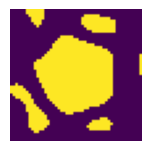

In [13]:
display_unit_image_selection(experiment.results[0]["R_u_j1"], 50, 50)

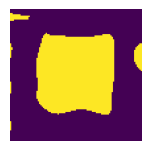

In [14]:
display_unit_image_selection(experiment.results[0]["R_u_j2"], 100, 100)

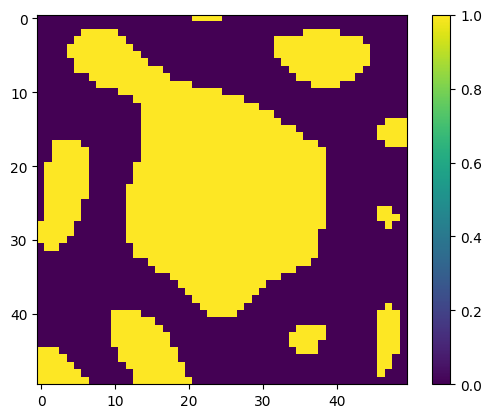

In [27]:
display_selection(experiment.results[12]["mask1"], 50, 50)

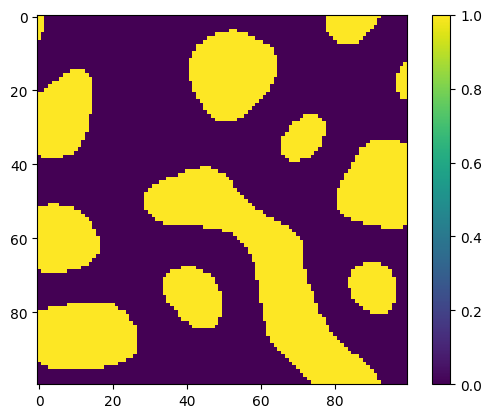

In [28]:
display_selection(experiment.results[12]["mask2"], 100, 100)